In [1]:
import numpy as np
import torch

from torchgpe.bec2D import Gas
from torchgpe.bec2D.potentials import LinearPotential, Union, Callable, any_time_dependent_variable, time_dependent_variable
from torchgpe.utils.potentials import NonLinearPotential

import sys
import importlib
sys.path.append('..')

import two_component_variable_gas
importlib.reload(two_component_variable_gas)
from two_component_variable_gas import TwoComponentGas

import peden_two_state_3D
importlib.reload(peden_two_state_3D)
from peden_two_state_3D import set_two_component_molecular_mass, Trap3D, PedenDirectDDI3D, initialize_two_component_gaussian, print_imaginary_time_stiffness
from peden_two_state_3D import plot_central_x_slices, plot_xy_density, plot_xz_density, DEBYE_TO_C_M, print_beta_and_D_from_gas_stark_shift

In [3]:
mass_amu = 220.0

# Quasi-2D / pancake trap.
# Frequencies must be angular frequencies, rad/s.
omega_x = 2 * np.pi * 400
omega_y = 2 * np.pi * 400
omega_z = 2 * np.pi * 4000

trap = Trap3D(
    omegax=omega_x,
    omegay=omega_y,
    omegaz=omega_z,
)

hbar = 1.054571817e-34
amu_to_kg = 1.6605e-27

ellz = np.sqrt(hbar/mass_amu/omega_z/amu_to_kg)
print(ellz)

N_up = int(50)
N_down = int(50)

gas = TwoComponentGas(
    element="87Rb",
    N_particles=(N_up, N_down),
    N_grid=64,
    grid_size=(3000e-9, 3000e-9, 1000e-9),
    adimensionalization_length=ellz,
    device="cuda",
)

1.0717348922623537e-07


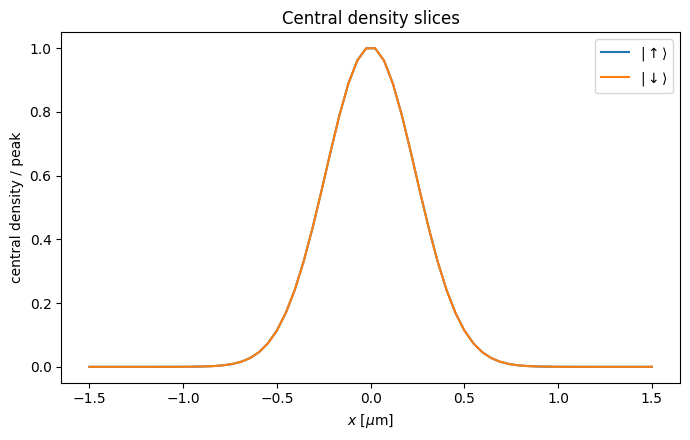

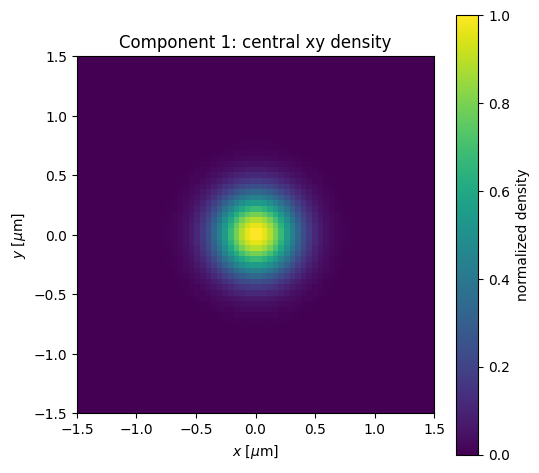

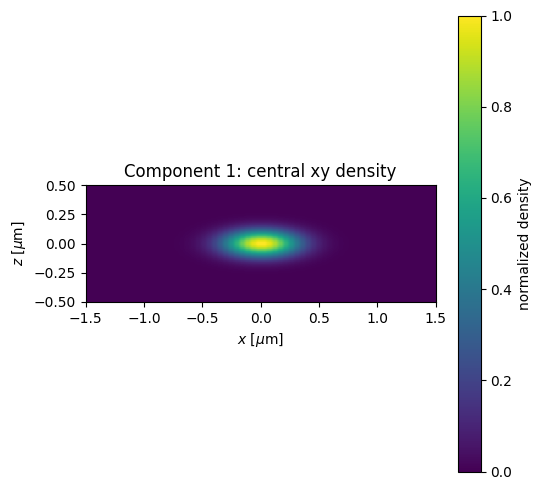

{'converged': True, 'stop_reason': 'energy_convergence', 'converged_iteration': 200, 'converged_rel_delta_E': 7.258019779081335e-13, 'last_iteration': 200, 'last_energy': -0.8142327163549994, 'last_rel_delta_E': 7.258019779081335e-13, 'rtol': 1e-12, 'compute_every': 10, 'stable_checks': 1}


In [9]:
import pickle

set_two_component_molecular_mass(gas, mass_amu=mass_amu)

for beta in [1]:
    for D in np.arange(0, 2500, 25):
        with open(f"compress/beta{beta:.2f}/beta{beta:.2f}_D{int(D)}.pkl", "rb") as f:
            data = pickle.load(f)

            psi = data["psi"]
            summary = data["summary"]

            gas.psi = psi

            plot_central_x_slices(gas, normalize=True)
            plot_xy_density(gas, component=0, normalize=True)
            plot_xz_density(gas, component=0, normalize=True)

            print(summary)
            break